# Supplemental Figure 7

In [1]:
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(arrow))
suppressPackageStartupMessages(library(RColorBrewer))

Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘patchwork’ was built under R version 4.2.3”
Warning message:
“package ‘arrow’ was built under R version 4.2.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.2.3”


In [2]:
figure_dir <- "../figures/supplementary"
output_supp_figure_7 <- file.path(
    figure_dir, "supp_figure_7_log_reg_pr_curves.png"
)
results_dir <- file.path(
    "./pr_results"
)

In [3]:
# Load data
PR_results_file <- file.path(results_dir, "pr_curve_all_plates.parquet")

PR_results_df <- arrow::read_parquet(PR_results_file)

dim(PR_results_df)
head(PR_results_df)

[1] 50162     7

model,split,precision,recall,threshold,plate,institution
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
final,train,0.4997616,1,5.438197e-07,ALL,ALL
final,train,0.4997914,1,8.835875e-07,ALL,ALL
final,train,0.4998212,1,6.761500e-06,ALL,ALL
final,train,0.4998510,1,8.327423e-06,ALL,ALL
final,train,0.4998808,1,2.239646e-05,ALL,ALL
final,train,0.4999106,1,2.725798e-05,ALL,ALL


## Generate PR curve for test/train/holdout splits from all plates

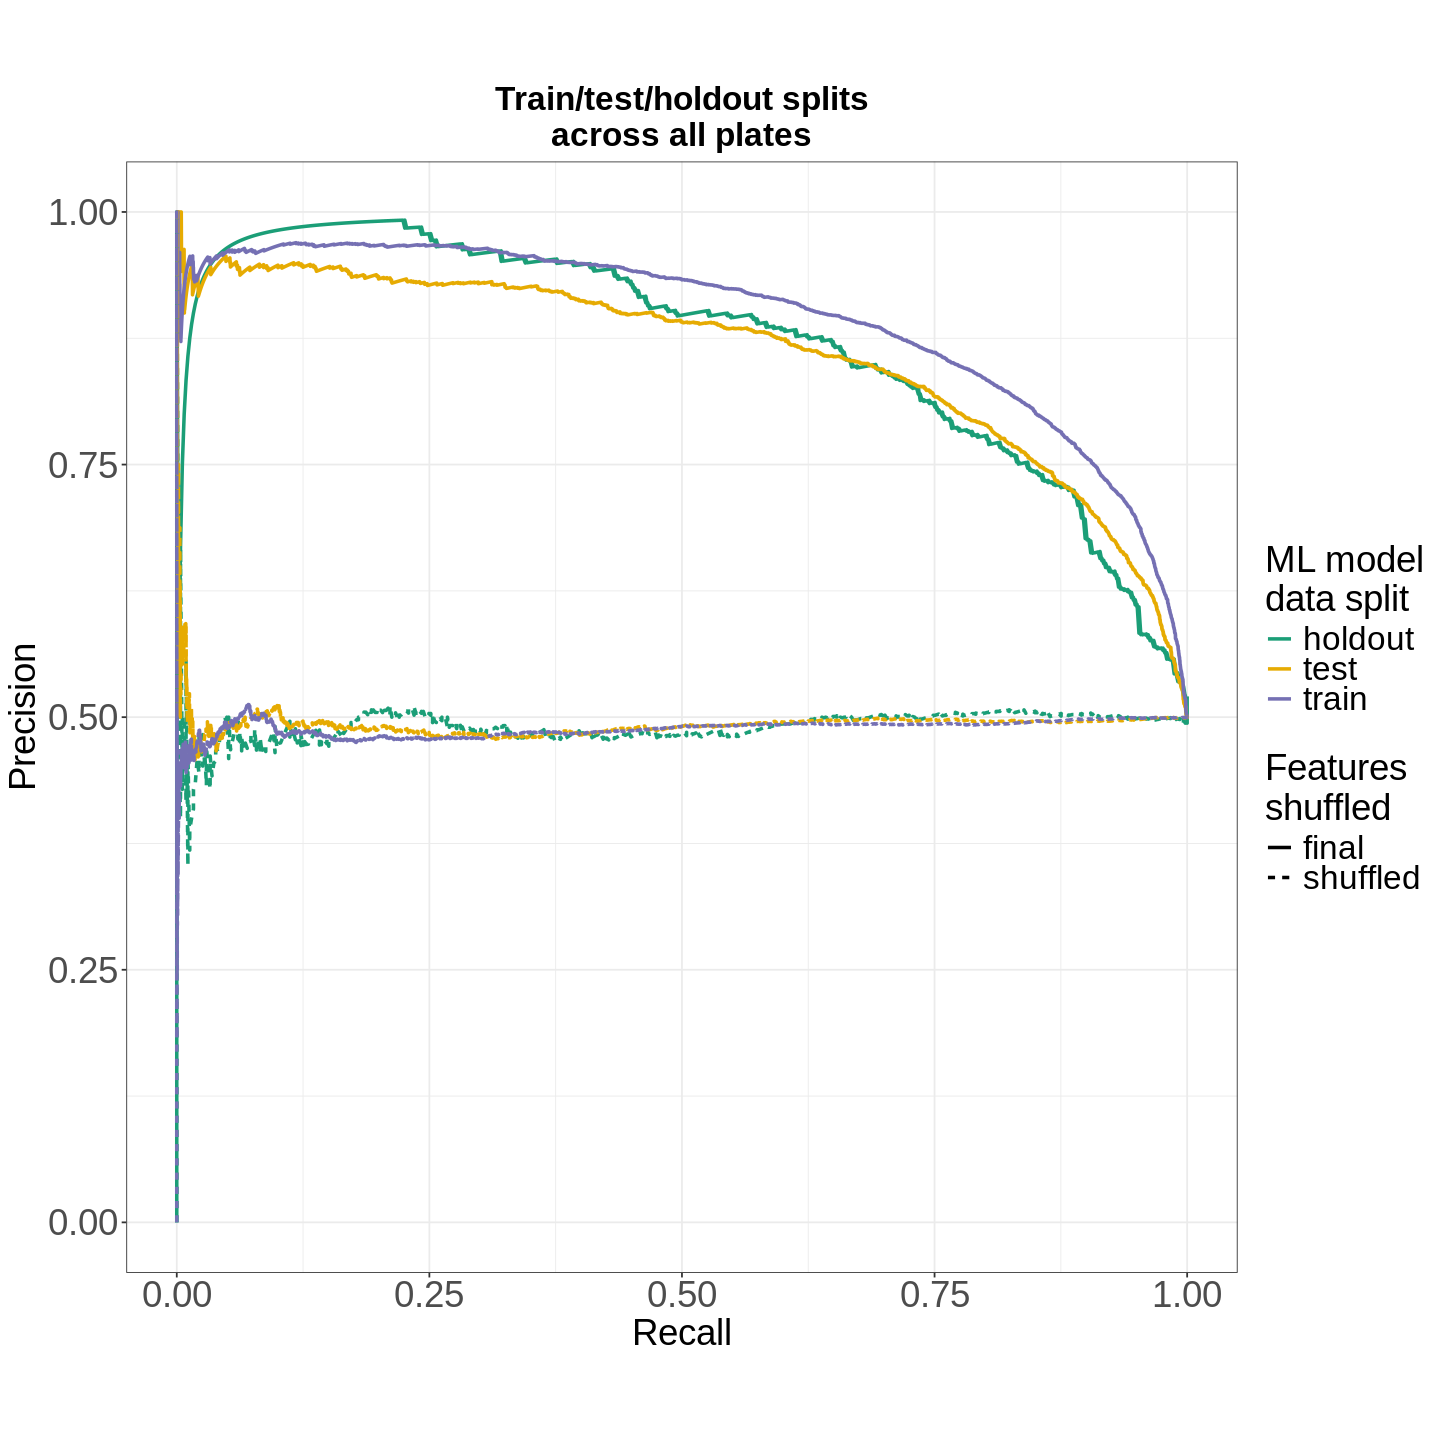

In [4]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)
pr_train_test_plot <- (
    ggplot(PR_results_df, aes(x = recall, y = precision, color = split, linetype = model))
    + geom_line(aes(linetype = model), linewidth = 1)
    + theme_bw()
    + coord_fixed()
    + labs(
        title = "Train/test/holdout splits\nacross all plates",
        color = "ML model\ndata split",
        linetype = "Features\nshuffled",
        x = "Recall",
        y = "Precision"
    )
    # change the colors
    + scale_color_manual(values = c(
        "test" = brewer.pal(8, "Dark2")[6],
        "train" = brewer.pal(8, "Dark2")[3],
        "holdout" = brewer.pal(8, "Dark2")[1]
    ))
    + scale_y_continuous(limits = c(0, 1))
    # change the line thickness of the lines in the legend
    + guides(linetype = guide_legend(override.aes = list(size = 1)))  
    # change the text size
    + theme(
        # x and y axis text size
        axis.text.x = element_text(size = 22),
        axis.text.y = element_text(size = 22),
        # x and y axis title size
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        # legend text size
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22),
        # plot title size
        plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
    )
)

pr_train_test_plot

In [5]:
# Load data
PR_results_file <- file.path(results_dir, "pr_curve_per_plate.parquet")

PR_results_df <- arrow::read_parquet(PR_results_file)

# Update plate names
PR_results_df <- PR_results_df %>%
    mutate(
        plate = recode(
            plate,
            "Plate_3" = "Plate_A",
            "Plate_3_prime" = "Plate_B",
            "Plate_5" = "Plate_C",
            "Plate_6" = "Plate_D"
        )
    )

dim(PR_results_df)
head(PR_results_df)

[1] 50180     7

model,split,precision,recall,threshold,plate,institution
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
final,train,0.4523432,1,5.438197e-07,Plate_A,ALL
final,train,0.4524084,1,6.761500e-06,Plate_A,ALL
final,train,0.4524737,1,8.327423e-06,Plate_A,ALL
final,train,0.4525389,1,4.487067e-05,Plate_A,ALL
final,train,0.4526042,1,6.559921e-05,Plate_A,ALL
final,train,0.4526696,1,8.869114e-05,Plate_A,ALL


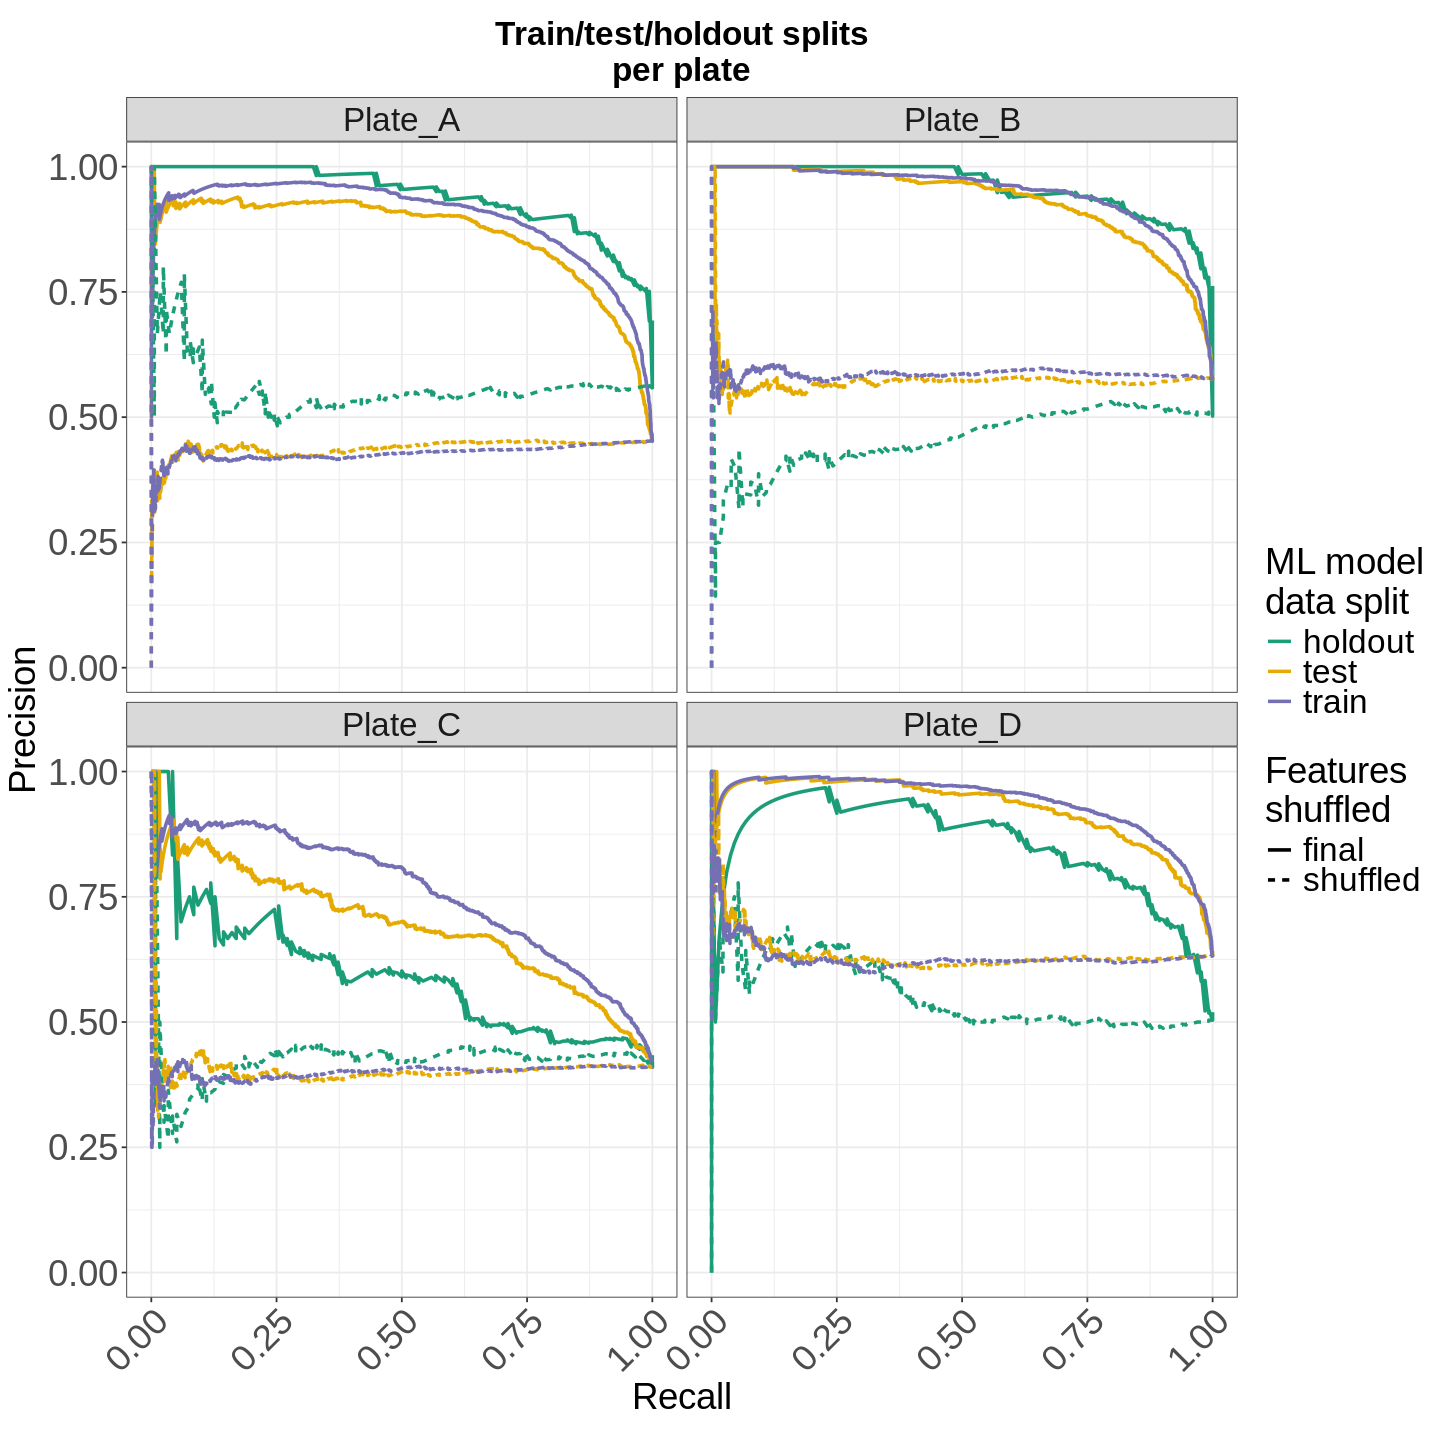

In [6]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)
pr_per_plate_plot <- (
    ggplot(PR_results_df, aes(x = recall, y = precision, color = split, linetype = model))
    + geom_line(aes(linetype = model), linewidth = 1)
    + theme_bw()
    + coord_fixed()
    + facet_wrap(~ plate, ncol = 2)
    + labs(
        title = "Train/test/holdout splits\nper plate",
        color = "ML model\ndata split",
        linetype = "Features\nshuffled",
        x = "Recall",
        y = "Precision"
    )
    # change the colors
    + scale_color_manual(values = c(
        "test" = brewer.pal(8, "Dark2")[6],
        "train" = brewer.pal(8, "Dark2")[3],
        "holdout" = brewer.pal(8, "Dark2")[1]
    ))
    + scale_y_continuous(limits = c(0, 1))
    # change the line thickness of the lines in the legend
    + guides(linetype = guide_legend(override.aes = list(size = 1)))  
    # change the text size
    + theme(
        # x and y axis text size
        axis.text.x = element_text(size = 22, angle = 45, hjust = 1),
        axis.text.y = element_text(size = 22),
        # x and y axis title size
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        # legend text size
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22),
        # strip text size for facets
        strip.text = element_text(size = 20),
        # plot title size
        plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
    )
)

pr_per_plate_plot

In [7]:
# Load data
PR_results_file <- file.path(results_dir, "pr_curve_plate6_per_institution.parquet")

PR_results_df <- arrow::read_parquet(PR_results_file)

# Add new column for cell line derivative
PR_results_df <- PR_results_df %>%
    mutate(cell_line_derivative = ifelse(institution == "iNFixion", "original", ifelse(institution == "MGH", "derivative", NA)))

dim(PR_results_df)
head(PR_results_df)

[1] 2486    8

model,split,precision,recall,threshold,plate,institution,cell_line_derivative
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
final,test,0.6076433,1,0.0008201027,Plate_6,MGH,derivative
final,test,0.6084184,1,0.0010972571,Plate_6,MGH,derivative
final,test,0.6091954,1,0.0015132713,Plate_6,MGH,derivative
final,test,0.6099744,1,0.0020874755,Plate_6,MGH,derivative
final,test,0.6107554,1,0.0026749489,Plate_6,MGH,derivative
final,test,0.6115385,1,0.0031830481,Plate_6,MGH,derivative


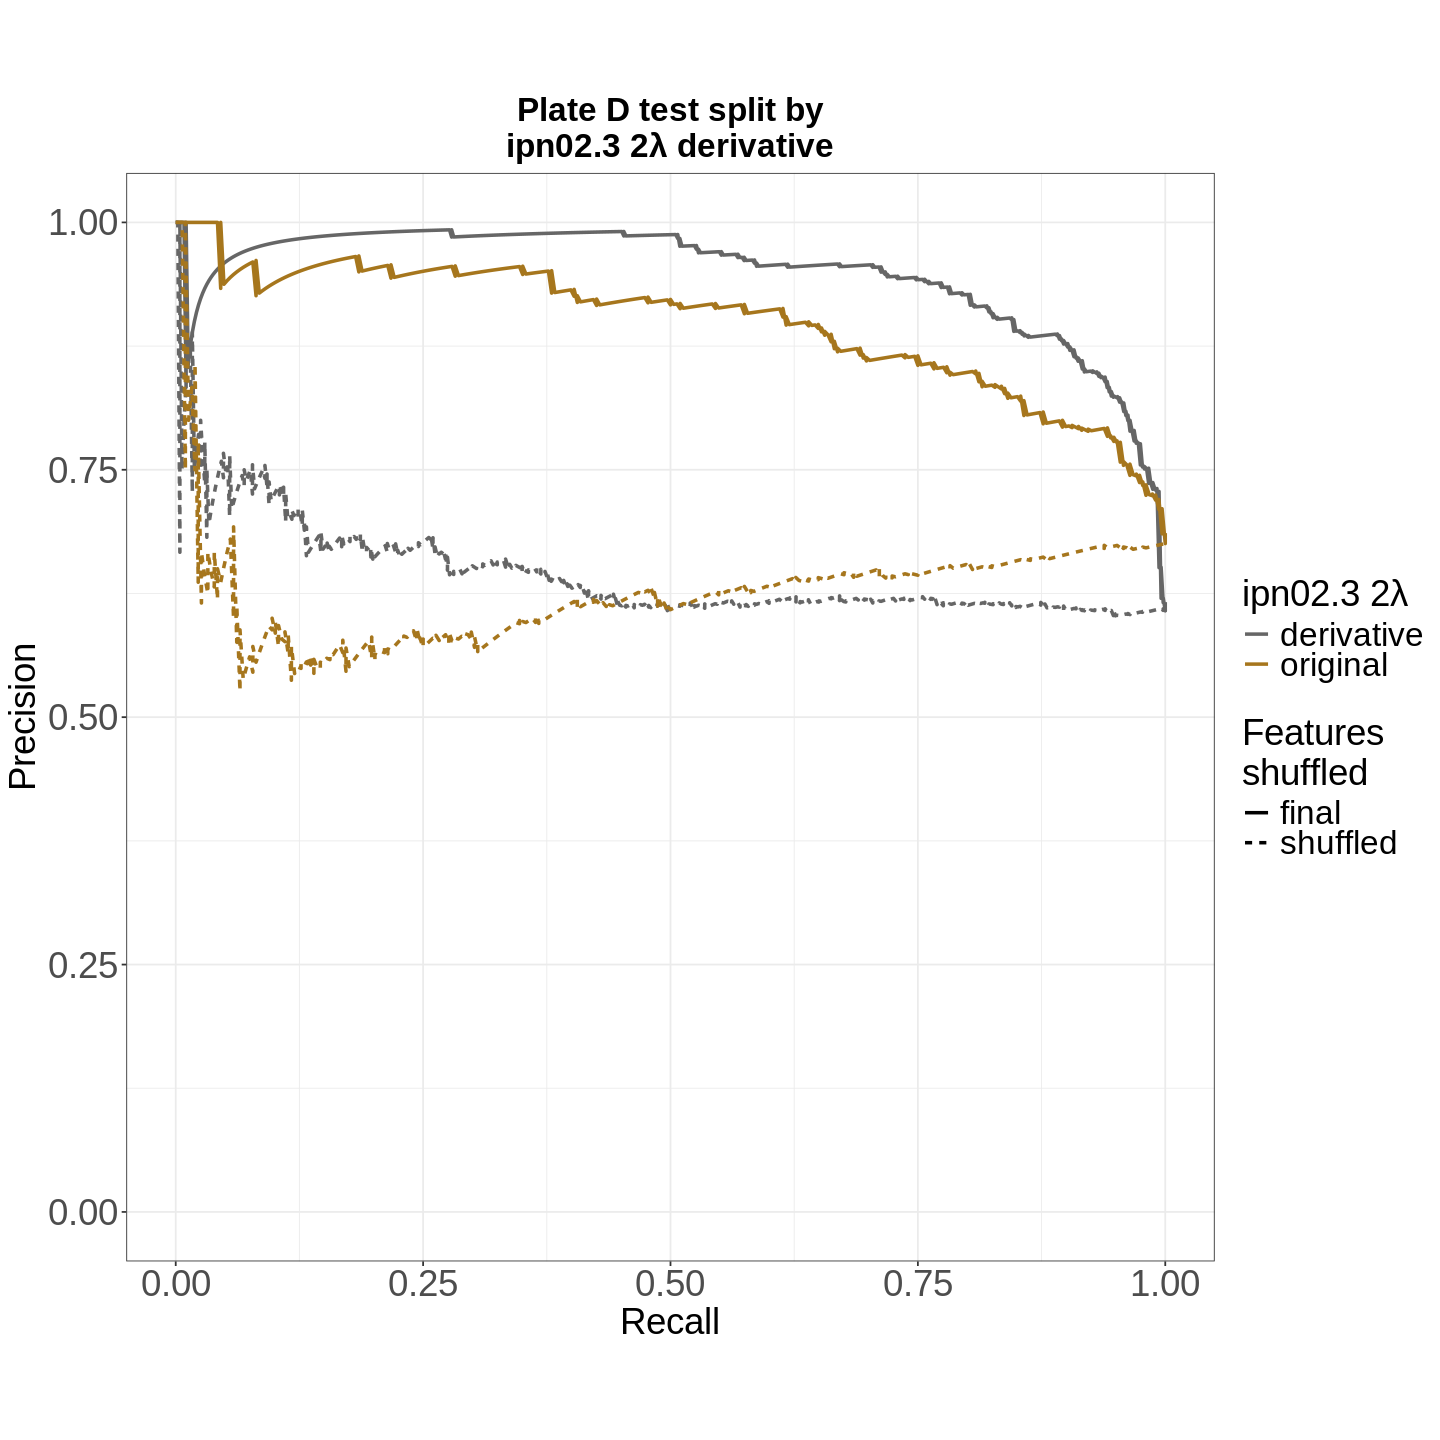

In [8]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)
pr_plate6_derivative_plot <- (
    ggplot(PR_results_df, aes(x = recall, y = precision, color = cell_line_derivative, linetype = model))
    + geom_line(aes(linetype = model), linewidth = 1)
    + theme_bw()
    + coord_fixed()
    + labs(
        title = "Plate D test split by\nipn02.3 2λ derivative",
        color = "ipn02.3 2λ",
        linetype = "Features\nshuffled",
        x = "Recall",
        y = "Precision"
    )
    # change the colors
    + scale_color_manual(values = c(
        "original" = brewer.pal(8, "Dark2")[7],
        "derivative" = brewer.pal(8, "Dark2")[8]
    ))
    + scale_y_continuous(limits = c(0, 1))
    # change the line thickness of the lines in the legend
    + guides(linetype = guide_legend(override.aes = list(size = 1)))  
    # change the text size
    + theme(
        # x and y axis text size
        axis.text.x = element_text(size = 22),
        axis.text.y = element_text(size = 22),
        # x and y axis title size
        axis.title.x = element_text(size = 22),
        axis.title.y = element_text(size = 22),
        # legend text size
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22),
        # plot title size
        plot.title = element_text(size = 20, face = "bold", hjust = 0.5)
    )
)

pr_plate6_derivative_plot

## Generate scatterplot with the original and new model coefficients

In [9]:
# Load the merged coefficients file
merged_coefficients_file <- "./coeff_results/merged_coefficients_original_new_model.csv"

if (file.exists(merged_coefficients_file)) {
    merged_coefficients <- read.csv(merged_coefficients_file)
    cat("Merged coefficients file loaded successfully.\n")
} else {
    stop("File not found:", merged_coefficients_file)
}

# Split the feature column into parts to add back as columns
feature_parts <- strsplit(merged_coefficients$feature, "_")

# Add feature parts as columns
merged_coefficients$compartment <- sapply(feature_parts, `[`, 1)
merged_coefficients$feature_group <- sapply(feature_parts, `[`, 2)
merged_coefficients$measurement <- sapply(feature_parts, `[`, 3)
merged_coefficients$organelle <- sapply(feature_parts, `[`, 4)
merged_coefficients$parameter1 <- sapply(feature_parts, `[`, 5)
merged_coefficients$parameter2 <- sapply(feature_parts, `[`, 6)
merged_coefficients$parameter3 <- sapply(feature_parts, `[`, 7)

# Replace invalid organelle values with "other"
merged_coefficients$organelle <- ifelse(
    is.na(merged_coefficients$organelle) |
        grepl("^[0-9]+$", merged_coefficients$organelle) |
        merged_coefficients$organelle %in% c("Adjacent", "X", "Y"),
    "other",
    merged_coefficients$organelle
)

# Update organelle names based on channel
merged_coefficients$organelle <- dplyr::recode(
    merged_coefficients$organelle,
    "DAPI" = "Nucleus",
    "GFP" = "ER",
    "RFP" = "Actin",
    "CY5" = "Mito",
    .default = merged_coefficients$organelle
)

# Display the first few rows of the loaded data
head(merged_coefficients)

Merged coefficients file loaded successfully.


,feature,coefficient_orig_model,coefficient_new_model,compartment,feature_group,measurement,organelle,parameter1,parameter2,parameter3
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Cytoplasm_RadialDistribution_ZernikePhase_GFP_7_3,0.04142596,0.05490171,Cytoplasm,RadialDistribution,ZernikePhase,ER,7,3,NA
2,Nuclei_RadialDistribution_ZernikePhase_CY5_7_5,0.02497480,0.02848109,Nuclei,RadialDistribution,ZernikePhase,Mito,7,5,NA
3,Nuclei_RadialDistribution_ZernikePhase_RFP_7_7,-0.01141866,-0.01757663,Nuclei,RadialDistribution,ZernikePhase,Actin,7,7,NA
4,Nuclei_RadialDistribution_ZernikeMagnitude_RFP_5_3,-0.05373913,0.02469489,Nuclei,RadialDistribution,ZernikeMagnitude,Actin,5,3,NA
5,Cells_RadialDistribution_RadialCV_GFP_1of4,0.01997790,0.00227299,Cells,RadialDistribution,RadialCV,ER,1of4,NA,NA
6,Nuclei_Intensity_LowerQuartileIntensity_GFP,-0.60101071,-0.34779991,Nuclei,Intensity,LowerQuartileIntensity,ER,NA,NA,NA


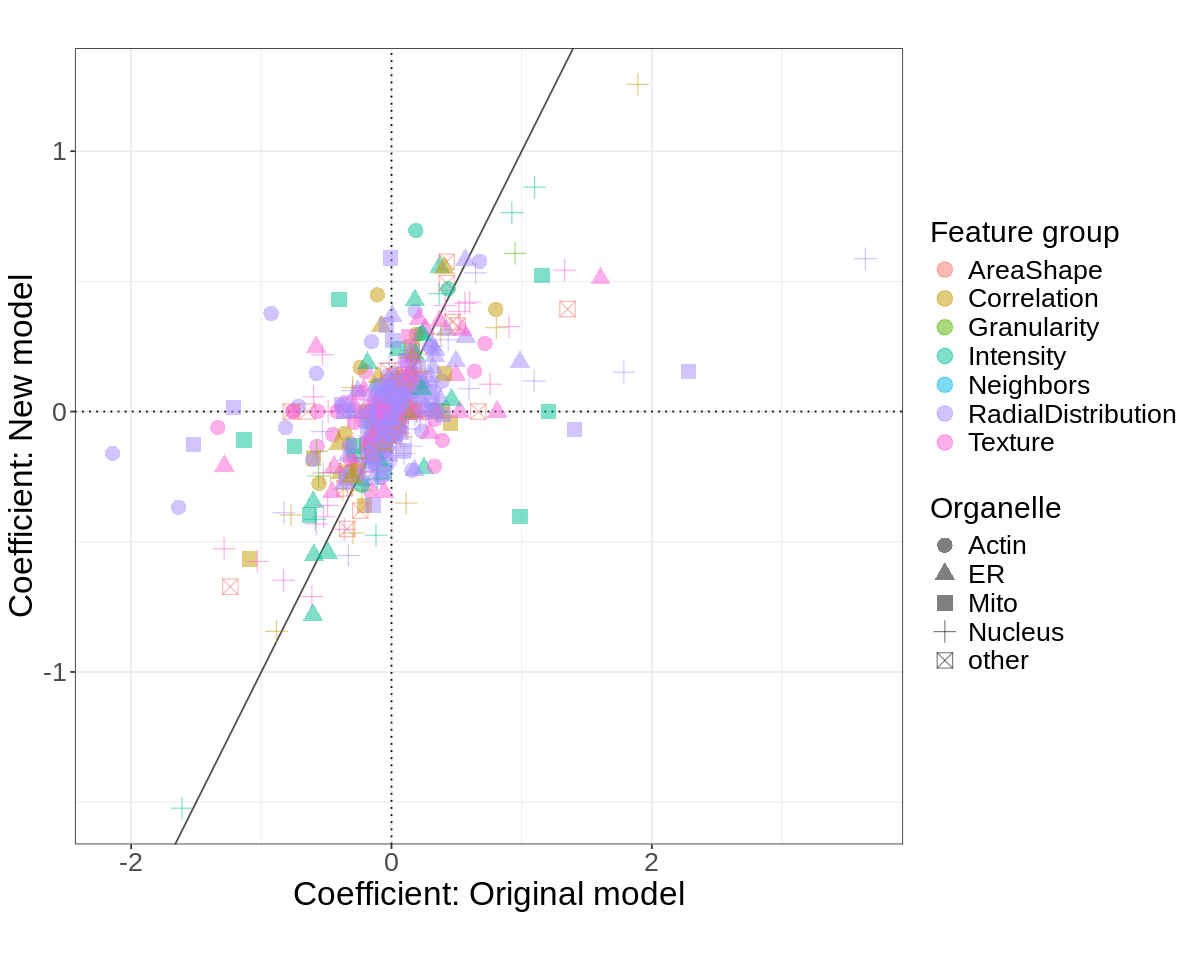

In [10]:
# Set height and width of plot for visualizing
width <- 10
height <- 8
options(repr.plot.width = width, repr.plot.height = height)

# Generate scatterplot of coefficients
scatterplot_models <- ggplot(merged_coefficients, aes(
    x = coefficient_orig_model, y = coefficient_new_model,
    color = feature_group, shape = organelle
)) +
    coord_fixed(ratio = 2) +
    geom_vline(xintercept = 0, linetype = "dotted", color = "black") +
    geom_hline(yintercept = 0, linetype = "dotted", color = "black") +
    geom_abline(slope = 1, intercept = 0, linetype = "solid", color = "gray30") +
    geom_point(size = 4, alpha = 0.5) +
    theme_bw() +
    theme(
        text = element_text(size = 18),
        axis.title = element_text(size = 20),
        axis.text = element_text(size = 16),
        legend.title = element_text(size = 18),
        legend.text = element_text(size = 16)
    ) +
    labs(
        x = "Coefficient: Original model",
        y = "Coefficient: New model",
        color = "Feature group",
        shape = "Organelle"
    )

# # Save coefficient plots
# ggsave(
#     filename = paste0(output_dir, "/circ_model_combined_batch1_scatterplot.png"), plot = scatterplot_models,
#     height = height, width = width, dpi = 500
# )

scatterplot_models

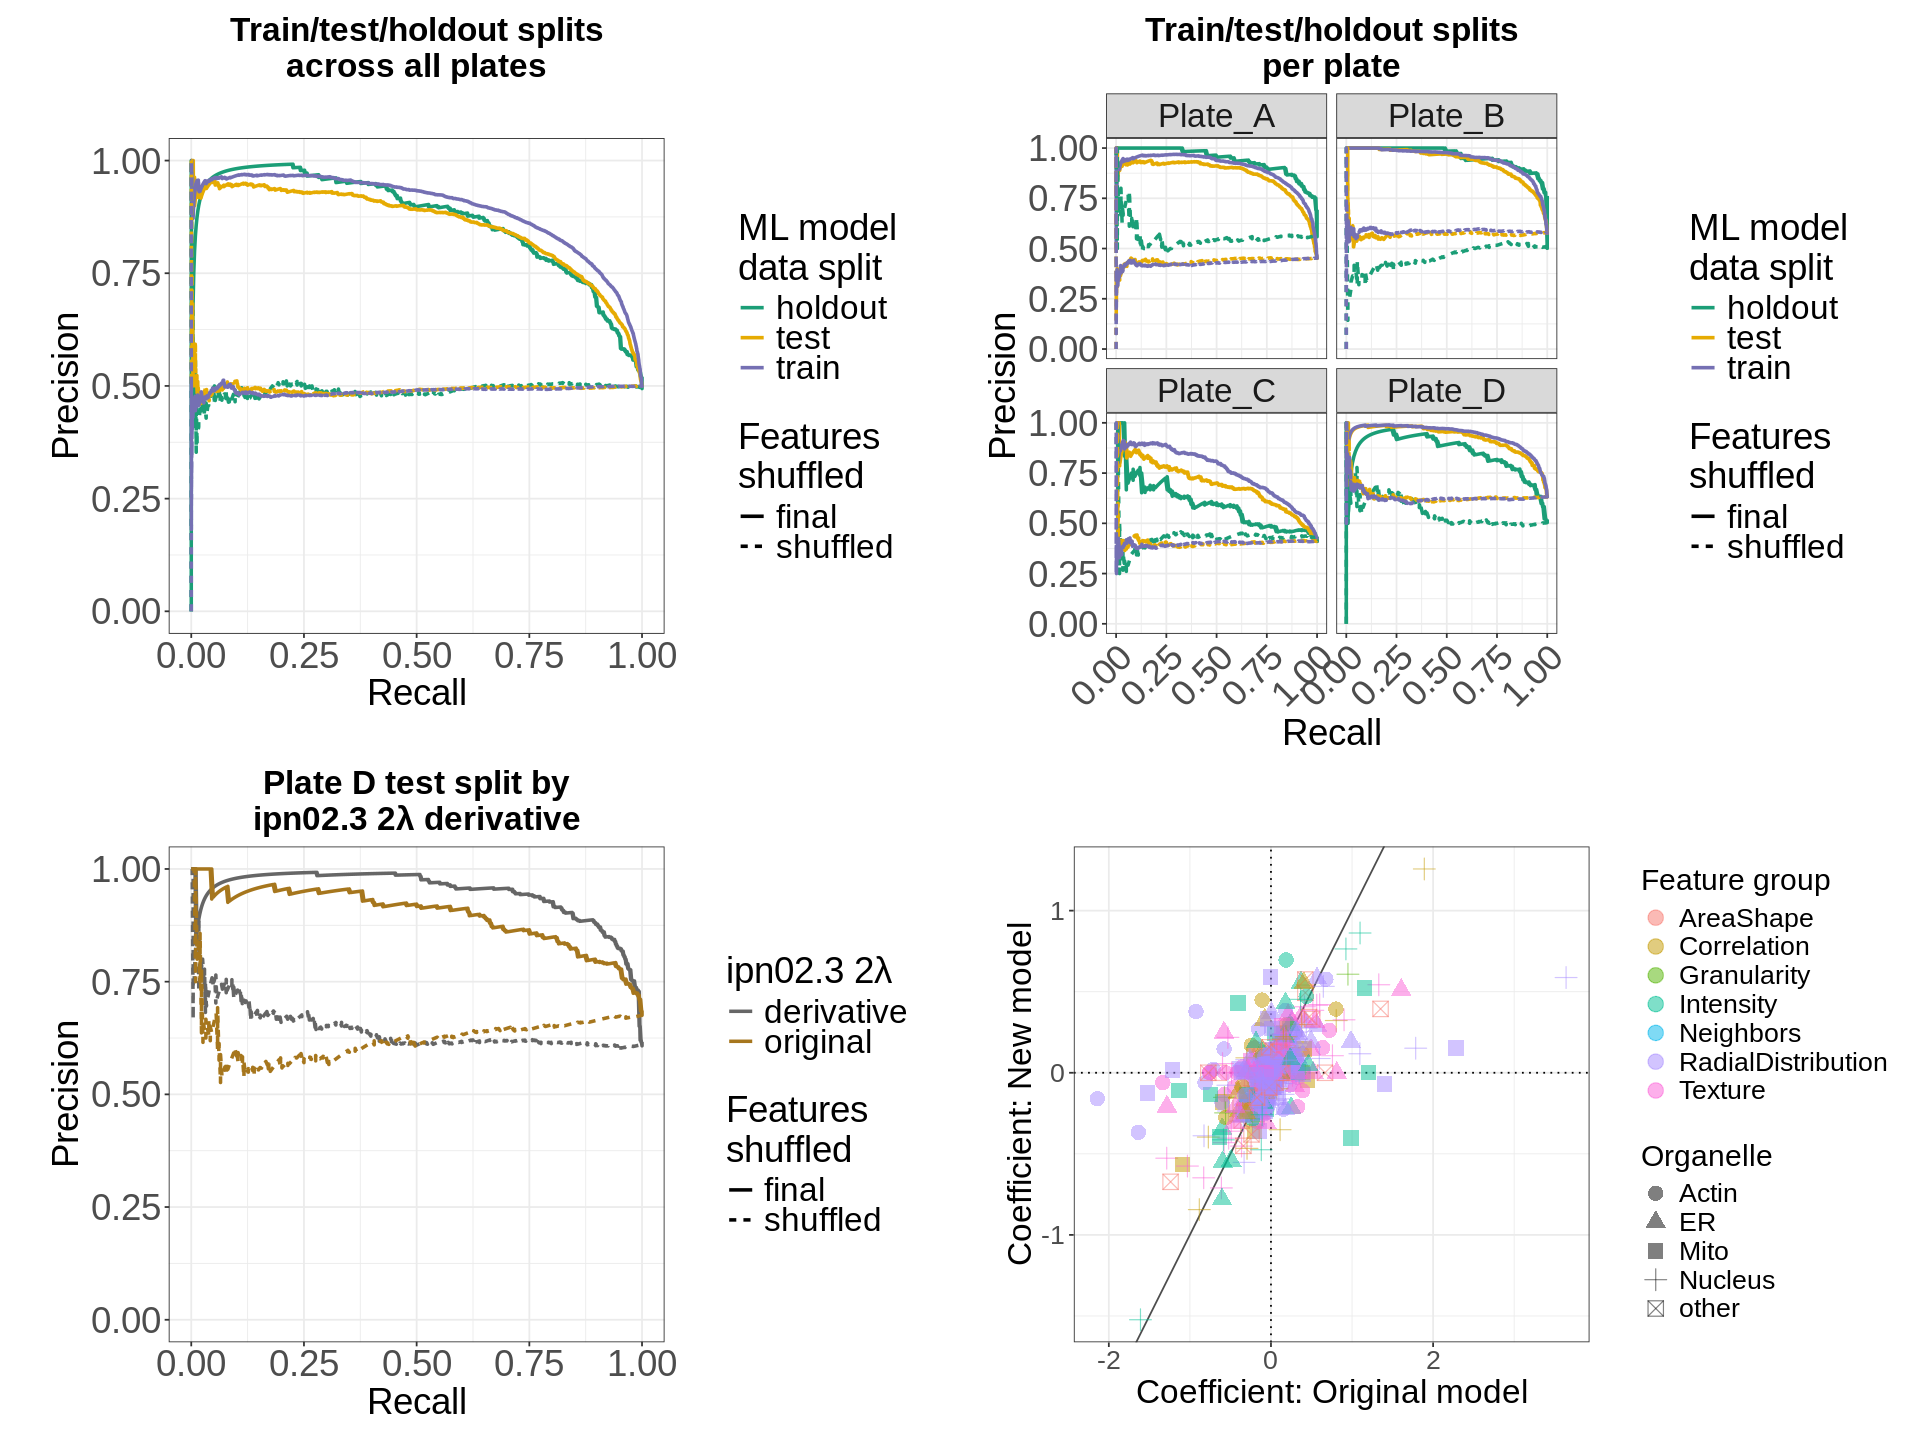

In [11]:
width <- 16
height <- 12
options(repr.plot.width = width, repr.plot.height = height)

align_plot <- 
    pr_train_test_plot + 
    pr_per_plate_plot + 
    pr_plate6_derivative_plot +
    scatterplot_models +
    plot_layout(ncol = 2, nrow = 2, widths = c(1,1,1,1))

align_plot

In [12]:
supp_fig_7_gg <- (
  align_plot + plot_annotation(tag_levels = list(c("A", "B", "C", "D"))) &
  theme(plot.tag = element_text(size = 30))
)

# Save or display the plot
ggsave(output_supp_figure_7, plot = supp_fig_7_gg, dpi = 500, height = height, width = width)